##### Time series prediction using XGBoost for price data (2008 - 2016)

* Training - 2008 to 2015
* Testing - 2016

In [1]:
!pip install xgboost statsmodels

In [2]:
!pip install prophet openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from datetime import datetime
from prophet import Prophet

color_pal = sns.color_palette()

In [4]:
# Override the default linewidth and markersize
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 5

In [5]:
# Import dataset
df = pd.read_csv('2008_2016.csv')
df = df.set_index('Date')
df.index = pd.to_datetime(df.index, format = '%m/%d/%y %H:%M')

**Side Note:**

---



**In order to represent a small geographical area having its own distribution network within New South Wales; we assume that the total demand at every time period at this location is 0.05% the total electricity demand in New South Wales, Australia.**

In [6]:
# Resample data to hourly intervals
df_hourly = df.resample('H').mean(numeric_only = True)

df_hourly['Demand'] = df_hourly['Demand'] * 0.0005

df_hourly

,Demand,Price
Date,,
2008-01-01 00:00:00,3.883800,26.660
2008-01-01 01:00:00,3.664215,24.910
2008-01-01 02:00:00,3.331627,24.360
2008-01-01 03:00:00,3.151432,20.310
2008-01-01 04:00:00,3.061030,16.795
...,...,...
2016-12-31 19:00:00,4.217613,50.780
2016-12-31 20:00:00,4.116238,47.250
2016-12-31 21:00:00,4.051337,44.840


In [7]:
# Define target test cutoff date

TARGET_TEST_CUTOFF_DATE = '2015-12-31 23:00:00'

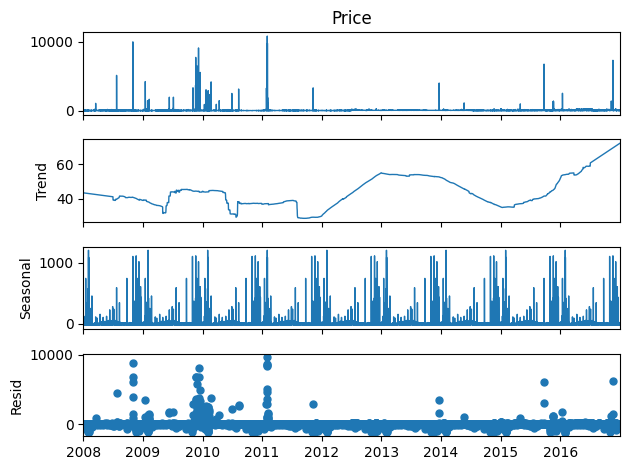

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

ANNUAL_PERIOD = 365*24
mult_decomp = seasonal_decompose(df_hourly['Price'], model = 'additive', extrapolate_trend = 'freq', period = ANNUAL_PERIOD)
mult_decomp.plot()
plt.show()

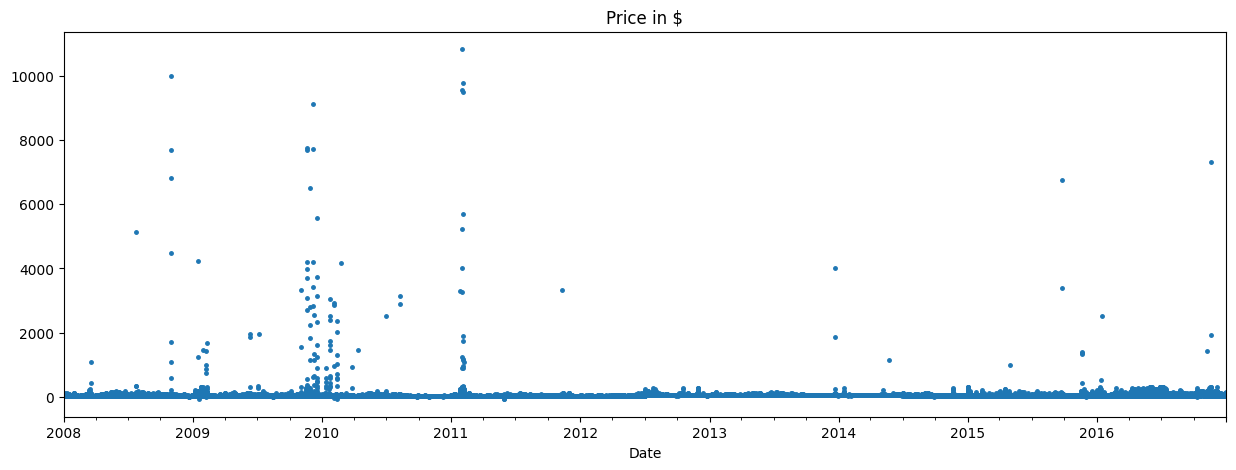

In [9]:
df_hourly['Price'].plot(style = '.',
               figsize = (15, 5),
               color = color_pal[0],
               title = 'Price in $')

plt.show()

In [10]:
train = df_hourly.loc[df_hourly.index <= TARGET_TEST_CUTOFF_DATE]
test = df_hourly.loc[df_hourly.index > TARGET_TEST_CUTOFF_DATE]

In [11]:
# Function for plotting train-test splits

def plot_train_test_split(df: pd.DataFrame, split_date: str) -> None:
  """
  Plots the train/test split of the input DataFrame.

  Args:
    df (pd.DataFrame): Input DataFrame with a DatetimeIndex
    split_date(str): Date in the format 'YYYY-MM-DD H:M:S' to split the DataFrame.

  Returns:
    None
  """

  train = df.loc[df.index <= split_date]
  test = df.loc[df.index > split_date]

  fig, ax = plt.subplots(figsize = (15, 5))
  train.plot(ax = ax, label = 'Training Set', title = 'Data Train/Test Split', linewidth = 1, markersize = 5)
  test.plot(ax = ax, label = 'Test Set', linewidth = 1, markersize = 5)
  ax.axvline(pd.Timestamp(split_date), color = 'black', ls = '--')
  ax.legend(['Training Set', 'Test Set'])
  plt.show()

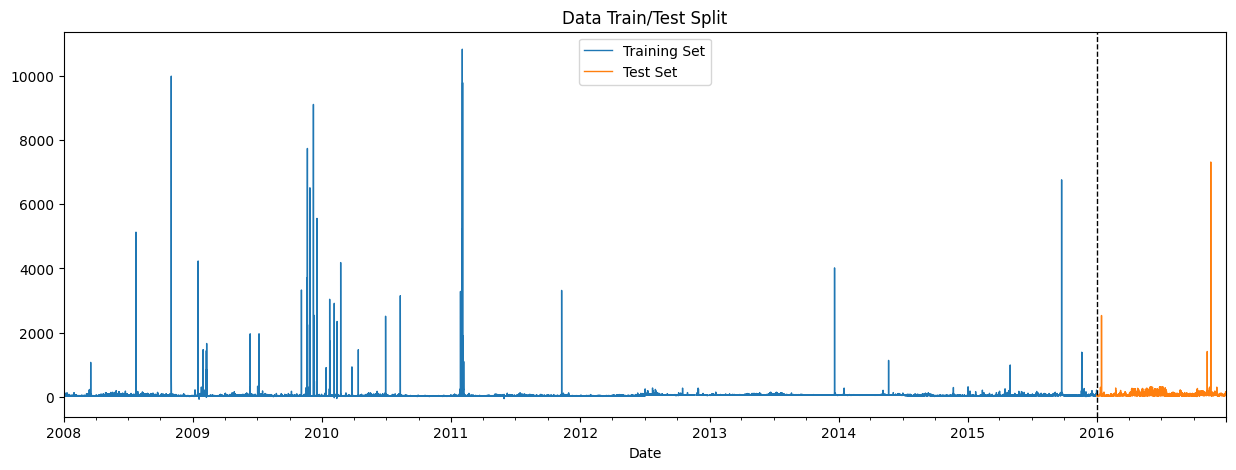

In [12]:
plot_train_test_split(df_hourly['Price'], TARGET_TEST_CUTOFF_DATE)

In [13]:
# Function for plotting between two date ranges. To see how a single weekly data looks like

def plot_week_of_data(df: pd.DataFrame, start_date: str, end_date: str) -> None:
  """
  Plot a week of data from the input DataFrame within a specified date range.

  Args:
    df (pd.DataFrame): Input DataFrame with a DatetimeIndex
    start_date(str): Start date in the format 'YYYY-MM-DD H:M:S'
    end_date(str): End date in the format 'YYYY-MM-DD H:M:S'

  Returns:
    None
  """
  df.loc[(df.index > start_date) & (df.index < end_date)].plot(figsize = (15, 5), \
                                    title = 'Week of Data', linewidth = 1, markersize = 5)

  plt.show()

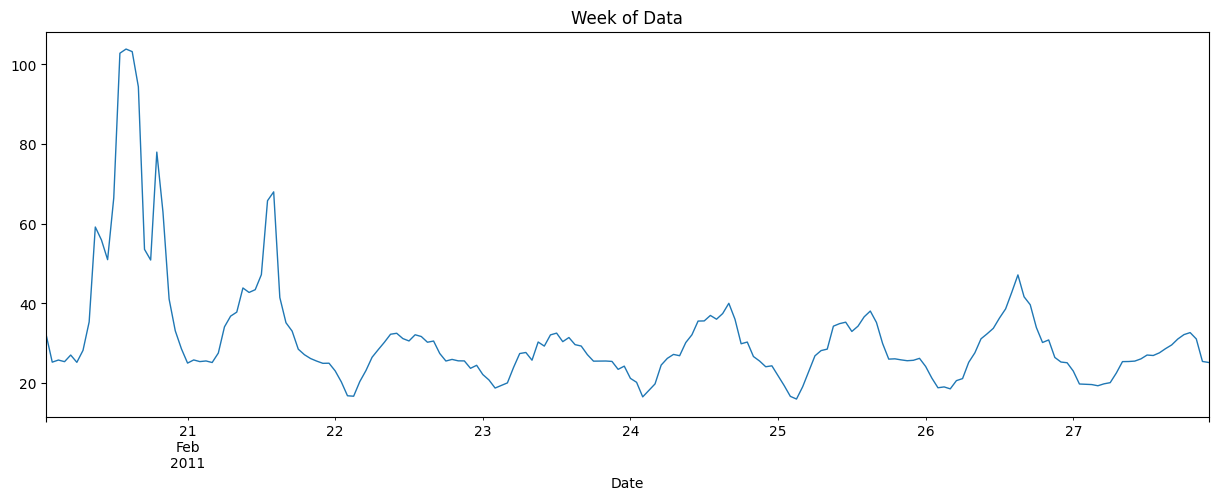

In [14]:
plot_week_of_data(df_hourly['Price'], '2011-02-20 00:00:00', '2011-02-27 23:00:00')

In [15]:
# Feature Engineeering for Time Series

def create_time_series_features(df: pd.DataFrame) -> pd.DataFrame:
  """
  From Date column of the original dataframe create features for the time series

  Args:
    df (pd.DataFrame): Input DataFrame with a Datetime Index

  Returns:
    pd.DataFrame: DataFrame with additional time series features

  Raises:
    ValueError: If input DataFrame does not have a Datetime Index.
  """

  if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("Input DataFrame must have a Datetime Index.")

  df = df.copy()

  features = {
      'hour': df.index.hour,
      'dayofweek': df.index.dayofweek,
      'quarter': df.index.quarter,
      'month': df.index.month,
      'year': df.index.year,
      'dayofyear': df.index.dayofyear,
      'dayofmonth': df.index.day,
      'weekofyear': df.index.isocalendar().week,
      'Price_lag1': df['Price'].shift(1),
      'Price_lag2': df['Price'].shift(2),
      'Price_lag3': df['Price'].shift(3),
      'Price_lag7': df['Price'].shift(7)
  }

  for feature_name, feature_values in features.items():
    df[feature_name] = feature_values

  return df

In [16]:
hourly_df = create_time_series_features(df_hourly)

In [17]:
hourly_df = hourly_df.dropna()

In [18]:
hourly_df.head()

,Demand,Price,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,Price_lag1,Price_lag2,Price_lag3,Price_lag7
Date,,,,,,,,,,,,,,
2008-01-01 07:00:00,3.382590,19.855,7,1,1,1,2008,1,1,1,19.055,17.030,16.795,26.660
2008-01-01 08:00:00,3.658960,20.720,8,1,1,1,2008,1,1,1,19.855,19.055,17.030,24.910
2008-01-01 09:00:00,3.910375,20.860,9,1,1,1,2008,1,1,1,20.720,19.855,19.055,24.360
2008-01-01 10:00:00,4.101945,24.665,10,1,1,1,2008,1,1,1,20.860,20.720,19.855,20.310
2008-01-01 11:00:00,4.248400,32.800,11,1,1,1,2008,1,1,1,24.665,20.860,20.720,16.795


##### Creating our Model

In [21]:
train.head()

,Demand,Price
Date,,
2008-01-01 00:00:00,3.883800,26.660
2008-01-01 01:00:00,3.664215,24.910
2008-01-01 02:00:00,3.331627,24.360
2008-01-01 03:00:00,3.151432,20.310
2008-01-01 04:00:00,3.061030,16.795


In [22]:
test.head()

,Demand,Price
Date,,
2016-01-01 00:00:00,3.488100,36.820
2016-01-01 01:00:00,3.293188,39.040
2016-01-01 02:00:00,3.016472,41.875
2016-01-01 03:00:00,2.889185,40.615
2016-01-01 04:00:00,2.858238,38.265


In [23]:
train = create_time_series_features(train)
train = train.dropna()
test = create_time_series_features(test)
test = test.dropna()

In [24]:
train['weekofyear'] = train['weekofyear'].astype('int32')
test['weekofyear'] = test['weekofyear'].astype('int32')

In [25]:
# Defining the train and test features & target for the TS

time_series_features = ['dayofyear', 'hour', 'dayofweek', 'weekofyear', 'quarter', 'month', 'year', 'Demand', 'Price_lag1',	'Price_lag2',	'Price_lag3',	'Price_lag7']

time_series_target = 'Price'

X_train = train[time_series_features]
y_train = train[time_series_target]

X_test = test[time_series_features]
y_test = test[time_series_target]

In [26]:
# XGBoost regressor function code

def train_xgb_regressor(X_train, y_train, X_test, y_test, use_gpu = False):
  """
  Train an XGBoost Regressor model using the provided training and test data

  Args:
    X_train: Training feature set.
    y_train: Training target set.
    X_test: Test feature set.
    y_test: Test target set.
    use_gpu (bool): Whether to use GPU for training. Default is False.

  Returns:
    xgb.XGBRegressor: Trained XGBoost Regressor model.
  """

  additional_params = {}
  if use_gpu:
    additional_params = {'tree_method': 'gpu_hist', 'gpu_id': 0}

  xgb_regressor = xgb.XGBRegressor(base_score = 0.5, booster = 'gbtree',
                                   n_estimators = 3000,
                                   early_stopping_rounds = 50,
                                   objective = 'reg:linear',
                                   max_depth = 6,
                                   learning_rate = 0.01,
                                   min_child_weight = 1,
                                   subsample = 0.8,
                                   colsample_bytree = 0.8,
                                   gamma = 0,
                                   reg_alpha = 0,
                                   reg_lambda = 1,
                                   **additional_params)
  xgb_regressor.fit(X_train, y_train,
                    eval_set = [(X_train, y_train), (X_test, y_test)],
                    verbose = 100)

  return xgb_regressor

In [27]:
model = train_xgb_regressor(X_train, y_train, X_test, y_test, use_gpu = False)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [08:32:49] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation_0-rmse:152.19610	validation_1-rmse:110.08174
[100]	validation_0-rmse:100.35284	validation_1-rmse:99.26624
[112]	validation_0-rmse:96.51622	validation_1-rmse:100.84991


##### Do a feature importance plot

In [28]:
# Plot feature importance

def plot_feature_importance(model):
  """
  Plot the feature importance of a trained XGBoost model

  Args:
    model (xgb.XGBRegressor): Trained XGBoost Regressor model.

  Returns:
    None
  """
  feat_importances = pd.DataFrame(data = model.feature_importances_,
                                  index = model.feature_names_in_,
                                  columns = ['importance'])
  feat_importances.sort_values('importance').plot(kind = 'barh', title = 'Feature Importance (Price, $)')

  plt.show()

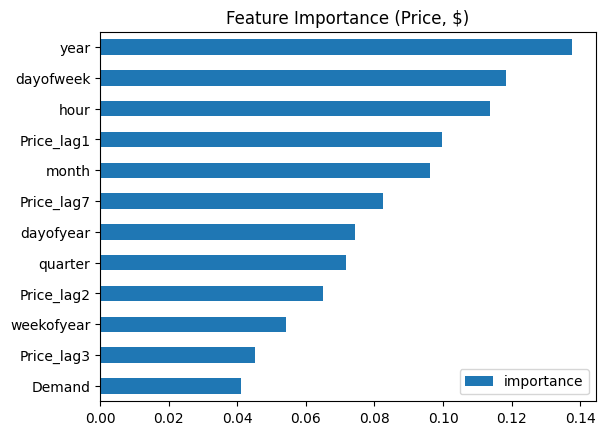

In [29]:
plot_feature_importance(model)

##### Inference on Test

In [30]:
test['prediction'] = model.predict(X_test)

hourly_df = hourly_df.merge(test[['prediction']], how = 'left', left_index = True, \
                            right_index = True)

In [31]:
hourly_df.tail()

,Demand,Price,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,Price_lag1,Price_lag2,Price_lag3,Price_lag7,prediction
Date,,,,,,,,,,,,,,,
2016-12-31 19:00:00,4.217613,50.780,19,5,4,12,2016,366,31,52,46.735,49.745,57.475,63.635,25.625607
2016-12-31 20:00:00,4.116238,47.250,20,5,4,12,2016,366,31,52,50.780,46.735,49.745,62.930,26.176867
2016-12-31 21:00:00,4.051337,44.840,21,5,4,12,2016,366,31,52,47.250,50.780,46.735,33.070,22.968206
2016-12-31 22:00:00,3.985603,45.380,22,5,4,12,2016,366,31,52,44.840,47.250,50.780,50.430,22.133976
2016-12-31 23:00:00,3.821210,42.025,23,5,4,12,2016,366,31,52,45.380,44.840,47.250,57.475,22.395554


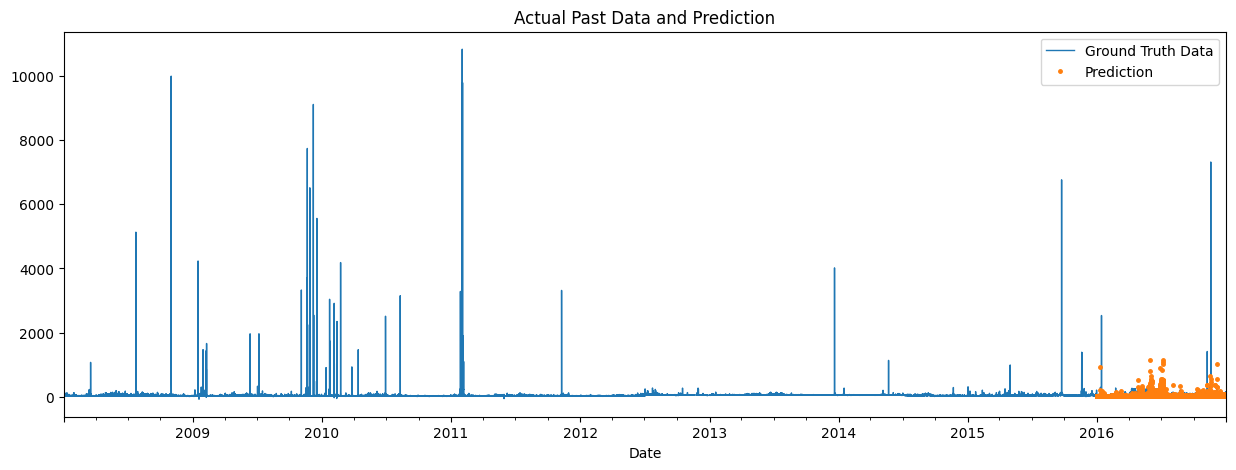

In [32]:
# Visualizing prediction against ground truth data

ax = hourly_df[['Price']].plot(figsize = (15, 5))

hourly_df['prediction'].plot(ax = ax, style = '.')

plt.legend(['Ground Truth Data', 'Prediction'])
ax.set_title('Actual Past Data and Prediction')

plt.show()

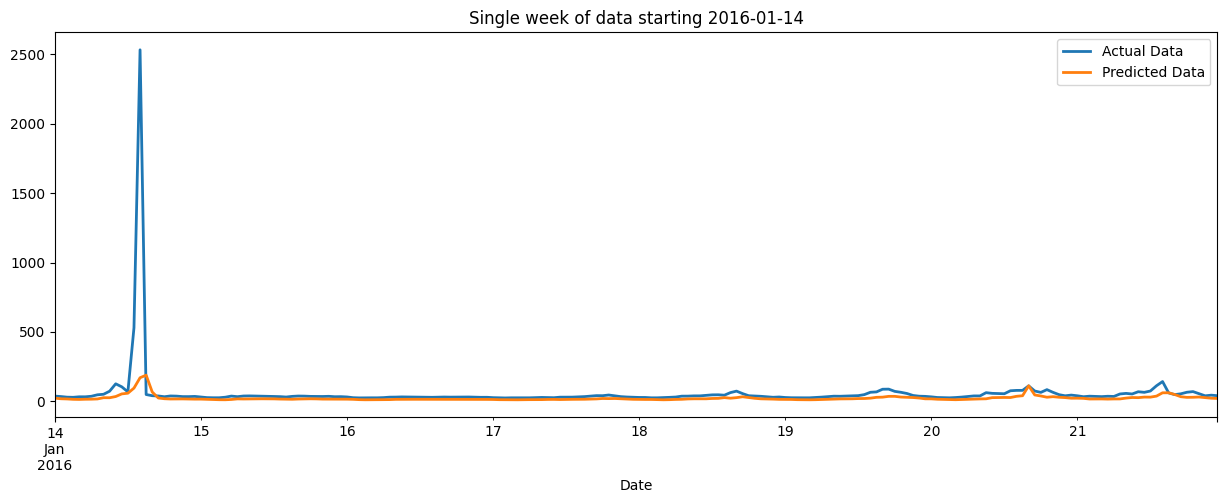

In [33]:
# Select Data within a certain date range

data = hourly_df.loc['2016-01-14':'2016-01-21']

# Plot the actual and predicted data
ax = data['Price'].plot(figsize = (15, 5), title = 'Single week of data starting 2016-01-14', linewidth = 2, markersize = 5)

data['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

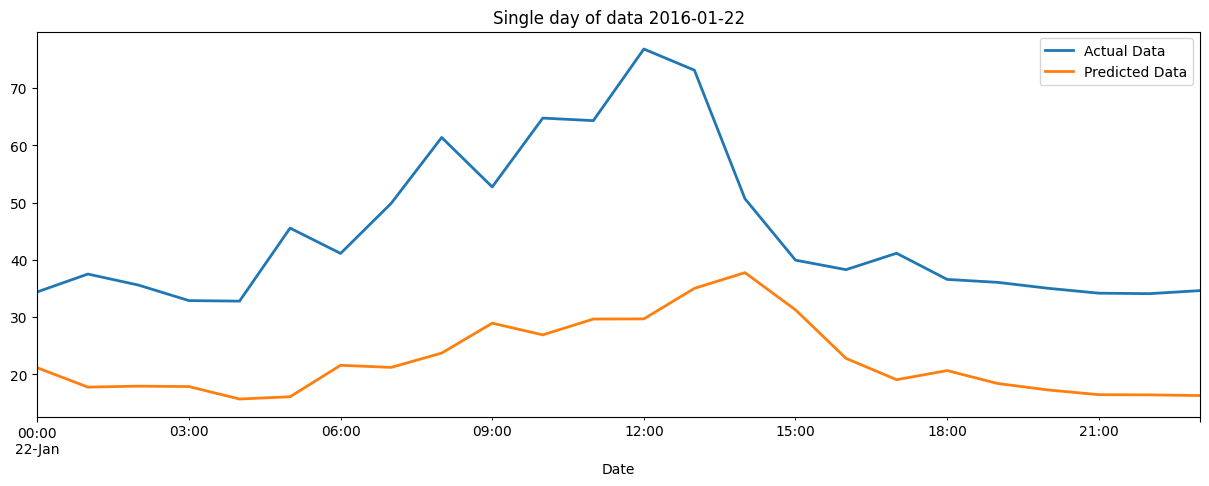

In [34]:
# Select data for all hours in a single day
data_one_day = hourly_df.loc['2016-01-22':'2016-01-22']

# Plot the actual and predicted data
ax = data_one_day['Price'].plot(figsize = (15, 5), title = 'Single day of data 2016-01-22', linewidth = 2, markersize = 5)

data_one_day['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

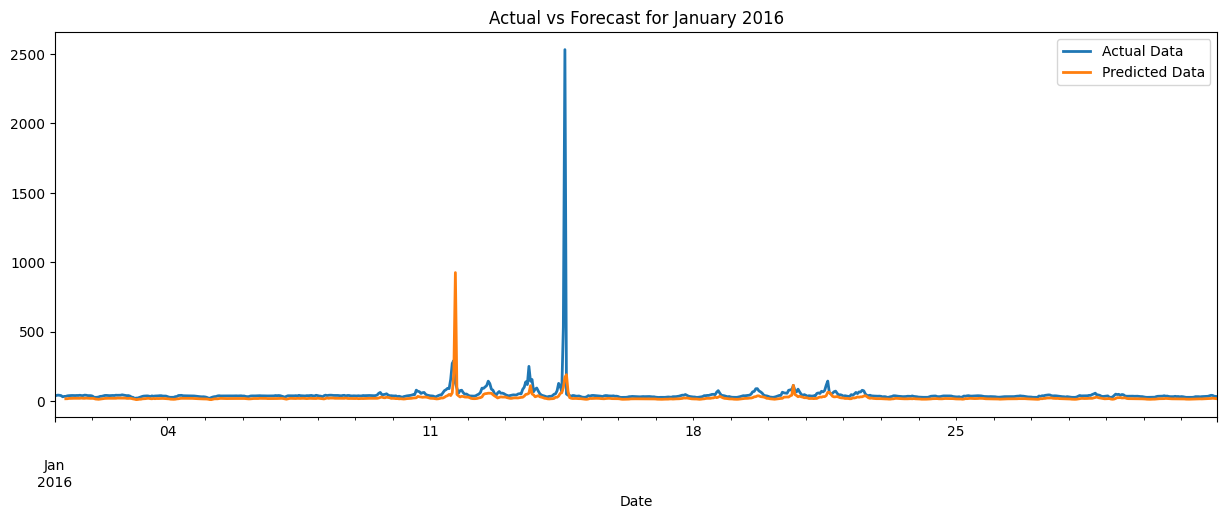

In [35]:
# For the whole of January

# Select data for the month of January

data_month = hourly_df.loc['2016-01-01':'2016-01-31']

# Plot the actual and predicted data
ax = data_month['Price'].plot(figsize = (15, 5), title = 'Actual vs Forecast for January 2016', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

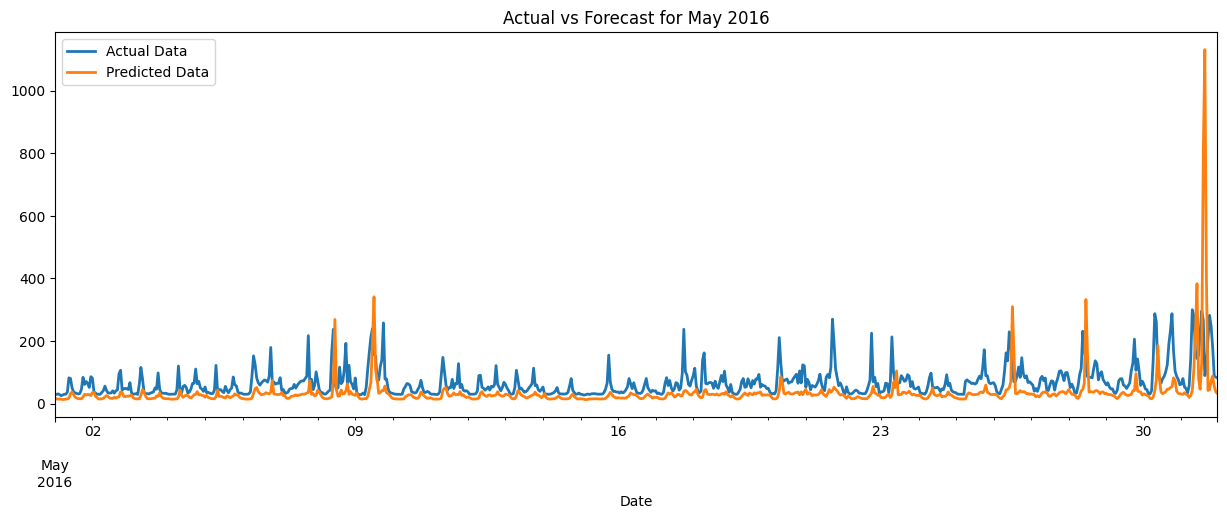

In [36]:
# For the whole of May

# Select data for the month of May

data_month = hourly_df.loc['2016-05-01':'2016-05-31']

# Plot the actual and predicted data
ax = data_month['Price'].plot(figsize = (15, 5), title = 'Actual vs Forecast for May 2016', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

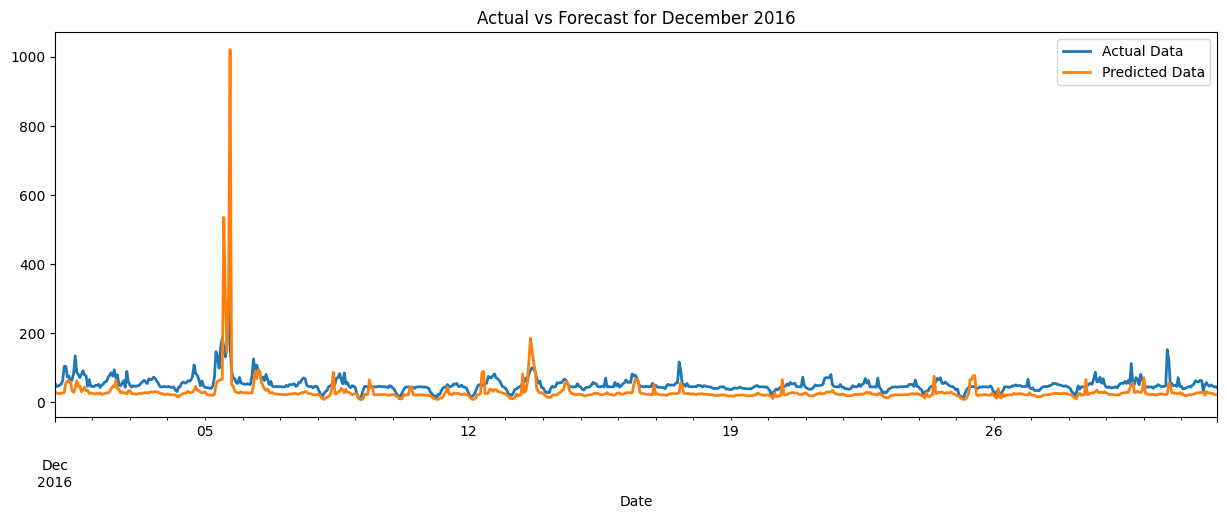

In [37]:
# For the whole of December

# Select data for the month of December

data_month = hourly_df.loc['2016-12-01':'2016-12-31']

# Plot the actual and predicted data
ax = data_month['Price'].plot(figsize = (15, 5), title = 'Actual vs Forecast for December 2016', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

##### RMSE

In [38]:
score = np.sqrt(mean_squared_error(test['Price'], test['prediction']))

print(f'RMSE Score on Test set: {score: 0.2f}')

RMSE Score on Test set:  97.05


In [39]:
# Compute the error of each forecast

test['error_price'] = np.abs(test['Price'] - test['prediction'])

In [40]:
# Compute the error of each forecast

test['error_price_raw'] = test['Price'] - test['prediction']

In [41]:
test.head()

,Demand,Price,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,Price_lag1,Price_lag2,Price_lag3,Price_lag7,prediction,error_price,error_price_raw
Date,,,,,,,,,,,,,,,,,
2016-01-01 07:00:00,3.028167,32.870,7,4,1,1,2016,1,1,53,32.680,30.075,38.265,36.820,15.673221,17.196779,17.196779
2016-01-01 08:00:00,3.207018,36.610,8,4,1,1,2016,1,1,53,32.870,32.680,30.075,39.040,15.971644,20.638356,20.638356
2016-01-01 09:00:00,3.347660,38.000,9,4,1,1,2016,1,1,53,36.610,32.870,32.680,41.875,18.239206,19.760794,19.760794
2016-01-01 10:00:00,3.437667,38.505,10,4,1,1,2016,1,1,53,38.000,36.610,32.870,40.615,18.205544,20.299456,20.299456
2016-01-01 11:00:00,3.517475,39.345,11,4,1,1,2016,1,1,53,38.505,38.000,36.610,38.265,19.000017,20.344983,20.344983


In [42]:
# Save the error in load demand (MW) for predicted year 2013

pred_2016_data = test[['error_price']]

import pickle

with open('error_price_2016.pickle', 'wb') as file:
  pickle.dump(pred_2016_data, file)